In [23]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import os
from torchvision import transforms, datasets
import torch.optim as optim

In [24]:
torch.manual_seed(42)  # For reproducibility
IMG_SIZE = 128
dataset= datasets.ImageFolder( root=r"F:\Work\ORANGE MODELS\MRI\Generate MRI Images for brain tumor", transform=transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),transforms.ToTensor(),transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]))

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [25]:
dataset_size = len(dataset)
print(f"Dataset size: {dataset_size} images")

Dataset size: 28894 images


In [26]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super(Generator, self).__init__()

        self.layers = nn.Sequential(

            # Input: (100, 1, 1)
            nn.ConvTranspose2d(noise_dim, 1024, 4, 1, 0, bias=False),
            nn.BatchNorm2d(1024),
            nn.ReLU(True),

            # (1024, 4, 4)
            nn.ConvTranspose2d(1024, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # (512, 8, 8)
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # (256, 16, 16)
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # (128, 32, 32)
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # (64, 64, 64)
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()

            # Output: (3, 128, 128)
        )

    def forward(self, x):
        return self.layers(x)



In [27]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.layers = nn.Sequential(

            # Input: (3, 128, 128)
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # (64, 64, 64)
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # (128, 32, 32)
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # (256, 16, 16)
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # (512, 8, 8)
            nn.Conv2d(512, 1024, 4, 2, 1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.2, inplace=True),

            # (1024, 4, 4)
            nn.Conv2d(1024, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()

            # Output: (1, 1, 1)
        )

    def forward(self, x):
        return self.layers(x)

In [28]:
Generator=Generator().to(device)
Discriminator=Discriminator().to(device)
criterion = nn.BCELoss()
optimizer_G = optim.Adam(Generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(Discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [29]:
epochs = 100

Generator.train()
Discriminator.train()

for epoch in range(epochs):

    for i, (real_images, _) in enumerate(dataloader):

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # ---------------------
        # Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # Real images
        output_real = Discriminator(real_images).view(-1,1)
        loss_real = criterion(output_real, real_labels)

        # Fake images
        noise = torch.randn(batch_size, 100, 1, 1, device=device)
        fake_images = Generator(noise)

        output_fake = Discriminator(fake_images.detach()).view(-1,1)
        loss_fake = criterion(output_fake, fake_labels)

        loss_D = loss_real + loss_fake

        loss_D.backward()
        optimizer_D.step()

        # ---------------------
        # Train Generator
        # ---------------------

        optimizer_G.zero_grad()

        output = Discriminator(fake_images).view(-1,1)

        loss_G = criterion(output, real_labels)

        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

Epoch [1/100] | D Loss: 0.3514 | G Loss: 4.3806
Epoch [2/100] | D Loss: 0.2997 | G Loss: 3.9879
Epoch [3/100] | D Loss: 2.4888 | G Loss: 9.5806
Epoch [4/100] | D Loss: 0.5970 | G Loss: 1.3421
Epoch [5/100] | D Loss: 1.7855 | G Loss: 7.9243
Epoch [6/100] | D Loss: 0.8177 | G Loss: 1.8572
Epoch [7/100] | D Loss: 0.1735 | G Loss: 5.1483
Epoch [8/100] | D Loss: 0.5567 | G Loss: 8.7702
Epoch [9/100] | D Loss: 0.7251 | G Loss: 9.3182
Epoch [10/100] | D Loss: 0.4905 | G Loss: 7.8494
Epoch [11/100] | D Loss: 0.0628 | G Loss: 5.7481
Epoch [12/100] | D Loss: 0.1089 | G Loss: 5.6442
Epoch [13/100] | D Loss: 0.3147 | G Loss: 8.0494
Epoch [14/100] | D Loss: 0.0381 | G Loss: 5.4468
Epoch [15/100] | D Loss: 0.2009 | G Loss: 5.3425
Epoch [16/100] | D Loss: 0.2256 | G Loss: 7.6644
Epoch [17/100] | D Loss: 0.0465 | G Loss: 7.3049
Epoch [18/100] | D Loss: 0.5181 | G Loss: 9.6452
Epoch [19/100] | D Loss: 0.0509 | G Loss: 6.1606
Epoch [20/100] | D Loss: 0.0720 | G Loss: 5.3287
Epoch [21/100] | D Loss: 0.14

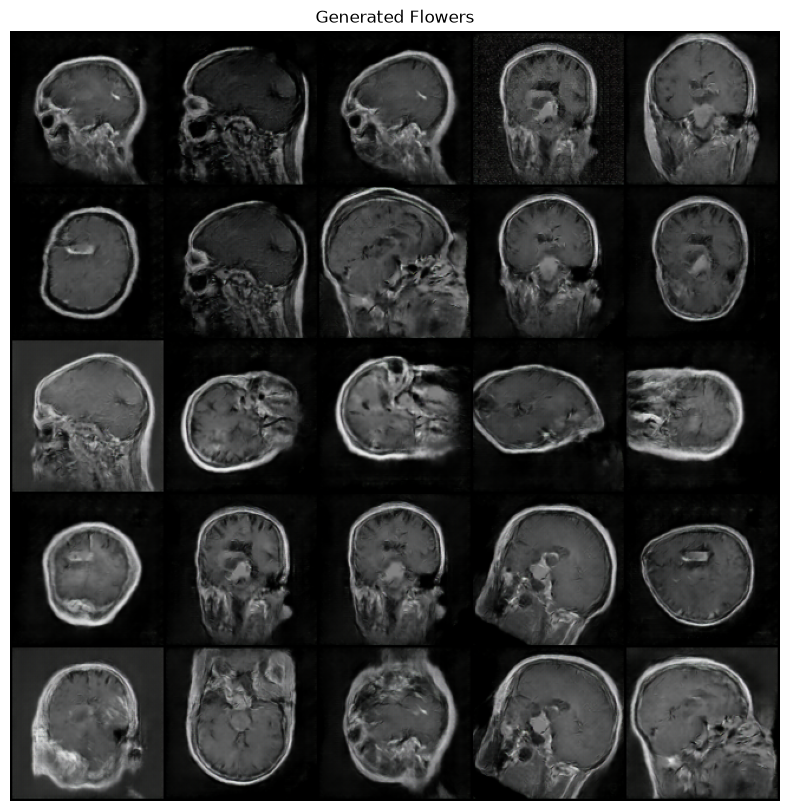

In [30]:
import torchvision
import matplotlib.pyplot as plt
Generator.eval()

with torch.no_grad():
    # Generate 25 random images
    noise = torch.randn(25, 100, 1, 1, device=device)
    fake_images = Generator(noise)

# Convert from [-1,1] to [0,1]
fake_images = (fake_images + 1) / 2

# Create a grid
grid = torchvision.utils.make_grid(fake_images.cpu(), nrow=5)

# Display
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Generated Flowers")
plt.show()

In [ ]:
import torch
import os

save_path = r"F:\Work\Python Learning" # Specify the path where you want to save the model
os.makedirs(save_path, exist_ok=True)

torch.save(Generator.state_dict(), os.path.join(save_path, "MRI of Brain Tumors.pth"))

print("Generator saved successfully!")

Generator saved successfully!


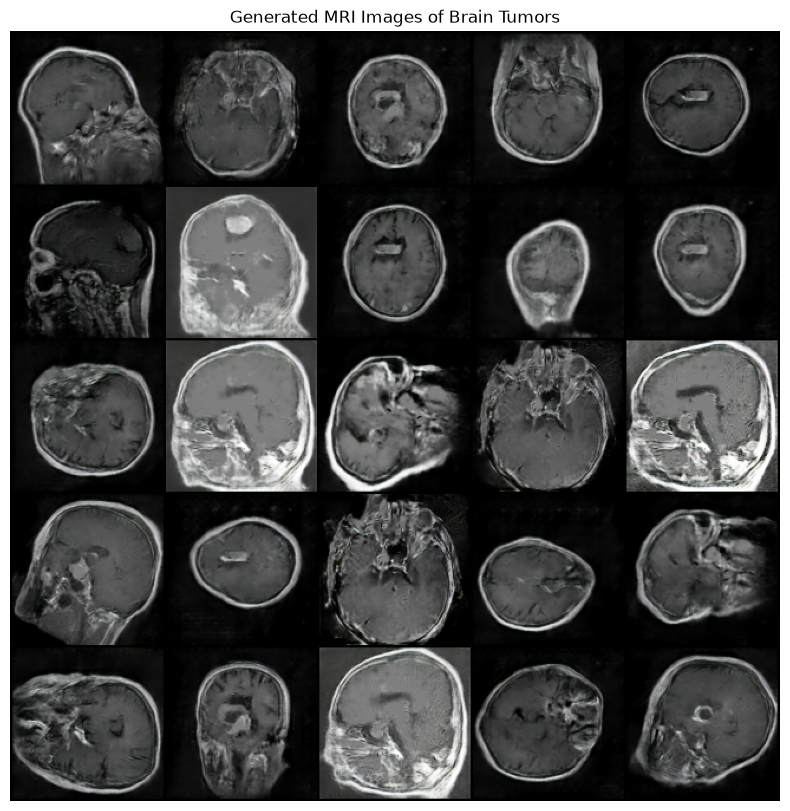

In [47]:
# Run This If you want to generate images from the trained Generator#
# Make sure that the path to the saved parameters is correct and the Generator class is defined in the same way as when it was saved.

import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------
# Generator
# ------------------------
class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super(Generator, self).__init__()

        self.layers = nn.Sequential(

            # Input: (100,1,1)
            nn.ConvTranspose2d(noise_dim, 1024, 4, 1, 0, bias=False),
            nn.BatchNorm2d(1024),
            nn.ReLU(True),

            # 4x4
            nn.ConvTranspose2d(1024, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # 8x8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 16x16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 32x32
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 64x64
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()

            # Output: (3,128,128)
        )

    def forward(self, x):
        return self.layers(x)

# ------------------------
# Load trained Generator
# ------------------------
Generator = Generator().to(device)

Generator.load_state_dict(
    torch.load(
        r"F:\Work\Python Learning\MRI of Brain Tumors.pth", # Specify the path to the saved model parameters
        map_location=device
    )
)

Generator.eval()

# ------------------------
# Generate Images
# ------------------------
with torch.no_grad():
    noise = torch.randn(25, 100, 1, 1, device=device)
    fake_images = Generator(noise)

# Convert from [-1,1] to [0,1]
fake_images = (fake_images + 1) / 2

grid = torchvision.utils.make_grid(fake_images.cpu(), nrow=5)

plt.figure(figsize=(10,10))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.title("Generated MRI Images of Brain Tumors")
plt.show()